In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import joblib
import os

# Get the path to the dataset
path = str(kagglehub.dataset_download("moltean/fruits"))
print("Path to dataset files:", path)

def create_csv(dataset_type):
    dataset_path = f'{path}/fruits-360_100x100/fruits-360/{dataset_type}'
    image_paths = []
    labels = []

    for label in os.listdir(dataset_path):
        label_path = os.path.join(dataset_path, label)
        if os.path.isdir(label_path):
            for image_name in os.listdir(label_path):
                if image_name.endswith('.jpg'):
                    image_paths.append(os.path.join(label, image_name))
                    labels.append(label)

    df = pd.DataFrame({
        'image': image_paths,
        'label': labels
    })

    csv_filename = f'fruits_{dataset_type.lower()}.csv'
    df.to_csv(csv_filename, index=False)
    print(f"{dataset_type} CSV saved at: {os.path.join(os.getcwd(), csv_filename)}")

# Create CSVs for training and testing datasets
create_csv('Training')
create_csv('Test')

train_csv = os.path.join(os.getcwd(), 'fruits_training.csv')
test_csv = os.path.join(os.getcwd(), 'fruits_test.csv')

# Load them into DataFrames
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

# Check the first few rows
print(train_df.head())
print(test_df.head())

def limit_classes(df, num_classes=50, samples_per_class=None, random_state=42):
    # Pick a subset of classes
    unique_classes = df["label"].unique()
    np.random.seed(random_state)
    selected_classes = np.random.choice(unique_classes, num_classes, replace=False)

    # Filter down to those classes
    df = df[df["label"].isin(selected_classes)]

    # Optionally, sample equal images per class
    if samples_per_class:
        df = df.groupby("label").apply(
            lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=random_state)
        ).reset_index(drop=True)

    return df


imgPerClass = 50

train_df = limit_classes(train_df, samples_per_class=imgPerClass)
test_df = limit_classes(test_df, samples_per_class=imgPerClass)

Path to dataset files: /root/.cache/kagglehub/datasets/moltean/fruits/versions/54
Training CSV saved at: /root/python/Fruit-Classification/fruits_training.csv
Test CSV saved at: /root/python/Fruit-Classification/fruits_test.csv
                       image       label
0  Cucumber 5/r0_124_100.jpg  Cucumber 5
1    Cucumber 5/r1_2_100.jpg  Cucumber 5
2    Cucumber 5/r2_1_100.jpg  Cucumber 5
3  Cucumber 5/r0_168_100.jpg  Cucumber 5
4  Cucumber 5/r2_201_100.jpg  Cucumber 5
                       image       label
0  Cucumber 5/r2_115_100.jpg  Cucumber 5
1  Cucumber 5/r1_135_100.jpg  Cucumber 5
2  Cucumber 5/r0_175_100.jpg  Cucumber 5
3  Cucumber 5/r2_111_100.jpg  Cucumber 5
4   Cucumber 5/r1_71_100.jpg  Cucumber 5


/tmp/ipykernel_111981/2547273871.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("label").apply(
/tmp/ipykernel_111981/2547273871.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("label").apply(


In [9]:
from sklearn.metrics import accuracy_score, classification_report
from concurrent.futures import ProcessPoolExecutor
from sklearn.preprocessing import LabelEncoder
from functools import partial
from PIL import Image
import numpy as np
import os

size = (64, 64)

def process_image(row, base_path, crop_size):
    image_path = os.path.join(base_path, row['image'])
    img = Image.open(image_path).convert('RGB')
    img = img.resize(crop_size)
    # use float32 for smaller memory footprint
    img_array = np.array(img, dtype=np.float32) / 255.0
    label = row['label']
    return img_array, label


def load_parallel(csv_df, base_path, crop_size=size, n_jobs=30):
    rows = csv_df.to_dict("records")
    n_samples = len(rows)
    
    # pre-allocate big array once
    X = np.empty((n_samples, crop_size[0], crop_size[1], 3), dtype=np.float32)
    y = [None] * n_samples

    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        func = partial(process_image, base_path=base_path, crop_size=crop_size)
        for i, (img_array, label) in enumerate(executor.map(func, rows, chunksize=50)):
            X[i] = img_array
            y[i] = label

    return X, np.array(y)


# usage
base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")
X_train, y_train = load_parallel(train_df, base_path_train)

base_path_val = os.path.join(path, "fruits-360_100x100/fruits-360/Test")
X_val, y_val = load_parallel(test_df, base_path_val)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Unique train labels:", np.unique(y_train))
print("Unique val labels:", np.unique(y_val))

# flatten for models that don’t support images directly
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)

# encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

print(y_train_enc[:20])
print(y_val_enc[:20])


Train: (2500, 64, 64, 3) Val: (2500, 64, 64, 3)
Unique train labels: ['Apple 14' 'Apple 5' 'Apple Golden 1' 'Apple Red Yellow 1'
 'Apple Red Yellow 2' 'Avocado ripe 1' 'Banana 4' 'Banana Lady Finger 1'
 'Beans 1' 'Beetroot 1' 'Blackberrie 1' 'Carambula 1' 'Carrot 1'
 'Cauliflower 1' 'Cherimoya 1' 'Cherry 3' 'Cherry 4' 'Cherry Sour 1'
 'Cherry Wax Red 1' 'Cherry Wax Red 2' 'Cherry Wax Yellow 1'
 'Cherry Wax not ripen 2' 'Chestnut 1' 'Cucumber 7' 'Eggplant long 1'
 'Ginger Root 1' 'Gooseberry 1' 'Granadilla 1' 'Grape Pink 1'
 'Grape White 3' 'Kaki 1' 'Mandarine 1' 'Mango Red 1'
 'Melon Piel de Sapo 1' 'Nut 1' 'Nut 3' 'Onion Red Peeled 1'
 'Onion White 1' 'Passion Fruit 1' 'Pear 6' 'Pear 7' 'Pear Forelle 1'
 'Plum 1' 'Plum 3' 'Pomelo Sweetie 1' 'Potato Red 1' 'Potato Sweet 1'
 'Strawberry Wedge 1' 'Tomato Cherry Yellow 1' 'Zucchini 1']
Unique val labels: ['Apple 14' 'Apple 5' 'Apple Golden 1' 'Apple Red Yellow 1'
 'Apple Red Yellow 2' 'Avocado ripe 1' 'Banana 4' 'Banana Lady Finger 1'
 'B

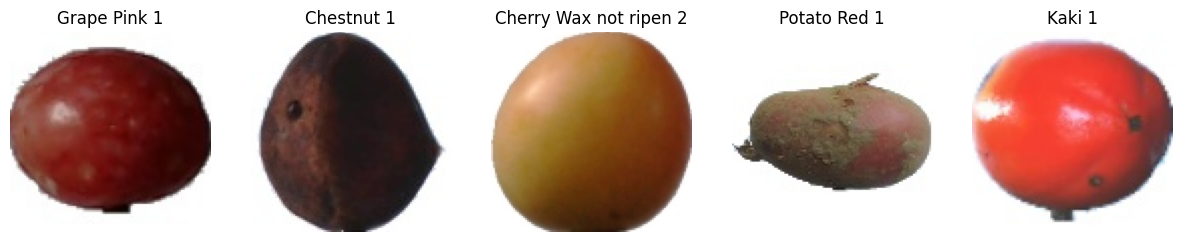

In [10]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

# Pick 5 random rows
sample_rows = train_df.sample(5, random_state=42)

# Set base path
base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")

# Create figure
plt.figure(figsize=(15, 5))

for i, (_, row) in enumerate(sample_rows.iterrows(), 1):
    img_path = os.path.join(base_path_train, row['image'])
    img = Image.open(img_path).convert('RGB')
    
    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.title(row['label'])
    plt.axis('off')

plt.show()


In [11]:
from collections import Counter

# Base path for training images
base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")

# Check shapes
shapes = []

for img_file in train_df['image']:
    img_path = os.path.join(base_path_train, img_file)
    try:
        img = Image.open(img_path).convert('RGB')
        shapes.append(img.size + (3,))  # (width, height, channels)
    except Exception as e:
        print(f"Error opening {img_path}: {e}")

# Count unique shapes
shape_counts = Counter(shapes)
print("Unique image shapes and counts:")
for shape, count in shape_counts.items():
    print(f"{shape}: {count}")

# Quick check
if len(shape_counts) == 1:
    print("All images have consistent shapes.")
else:
    print("Some images have inconsistent shapes.")

Unique image shapes and counts:
(100, 100, 3): 2500
All images have consistent shapes.


In [12]:
import hashlib

# Base path for training images
base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")

def file_hash(file_path):
    """Return MD5 hash of file contents."""
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for img_file in train_df['image']:
    img_path = os.path.join(base_path_train, img_file)
    try:
        h = file_hash(img_path)
        if h in hashes:
            duplicates.append((img_file, hashes[h]))  # (duplicate, original)
        else:
            hashes[h] = img_file
    except Exception as e:
        print(f"Error reading {img_path}: {e}")
# Base path for training images
base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")

def file_hash(file_path):
    """Return MD5 hash of file contents."""
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for img_file in train_df['image']:
    img_path = os.path.join(base_path_train, img_file)
    try:
        h = file_hash(img_path)
        if h in hashes:
            duplicates.append((img_file, hashes[h]))  # (duplicate, original)
        else:
            hashes[h] = img_file
    except Exception as e:
        print(f"Error reading {img_path}: {e}")

print(f"Total duplicate images found: {len(duplicates)}")

if duplicates:
    print("Some duplicate pairs (duplicate, original):")
    for dup in duplicates[:10]:  # show first 10
        print(dup)
else:
    print("No duplicates detected.")
print(f"Total duplicate images found: {len(duplicates)}")

if duplicates:
    print("Some duplicate pairs (duplicate, original):")
    for dup in duplicates[:10]:  # show first 10
        print(dup)
else:
    print("No duplicates detected.")

Total duplicate images found: 0
No duplicates detected.
Total duplicate images found: 0
No duplicates detected.


In [1]:
import joblib
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, make_scorer
from sklearn.preprocessing import LabelEncoder

# List of saved model files
model_files = [
    "lr_model.joblib",
    "knn_model.joblib",
    "dt_model.joblib",
    "rf_model.joblib",
    "xgb_model.joblib"
]

# Load models
models = {f.split("_")[1]: joblib.load(f) for f in model_files}

# Encode training labels
le = LabelEncoder()
y_enc = le.fit_transform(y_train)

# Flatten X_train if necessary
if X_train.ndim > 2:
    X_train_model = X_train.reshape(X_train.shape[0], -1)
else:
    X_train_model = X_train

# Stratified K-Fold for non-XGB models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics
scorers = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro")
}

# Open file to write results
with open("kfold_results.txt", "w") as f:
    for name, model in models.items():
        f.write(f"--- {name.upper()} ---\n")
        
        if name != "xgb":  # Use K-Fold for all except XGBoost
            for metric_name, scorer in scorers.items():
                try:
                    scores = cross_val_score(model, X_train_model, y_enc, cv=skf, scoring=scorer, n_jobs=-1)
                    f.write(f"{metric_name}: {scores.mean():.4f} ± {scores.std():.4f}\n")
                except Exception as e:
                    f.write(f"{metric_name}: FAILED ({e})\n")
        else:
            # For XGBoost, evaluate on testing set
            X_test, y_test = load_parallel(test_df, path, target_size=(32,32))  # Process testing set
            if X_test.ndim > 2:
                X_test = X_test.reshape(X_test.shape[0], -1)
            y_test_enc = le.transform(y_test)

            try:
                y_pred = model.predict(X_test)
                f.write(f"accuracy: {accuracy_score(y_test_enc, y_pred):.4f}\n")
                f.write(f"f1_macro: {f1_score(y_test_enc, y_pred, average='macro'):.4f}\n")
            except Exception as e:
                f.write(f"FAILED ({e})\n")
        
        f.write("\n")


NameError: name 'y_train' is not defined